## Statistical Modelling. Lecture 6 Example

Multiple Linear Regression: 
- Least squares estimation
- Confidence and prediction intervals

---

A soft drink bottler is analysing the vending machine service routes in his distribution system. He is interested in predicting the amount of time required by the route driver to service the vending machines in an outlet. This service activity includes stocking the machine with beverage products and minor maintenance or housekeeping. 

The analyst responsible for the study has suggested that the two most important variables affecting the delivery time ($y$) are:
- the number of cases of product stocked ($x_1$), and
- the distance walked by the route driver ($x_2$).

The analyst has collected 25 observations on delivery time, which are given in [https://raw.githubusercontent.com/uqglmn/sm/main/mlr/delivery.csv](https://raw.githubusercontent.com/uqglmn/sm/main/mlr/delivery.csv)

---

### Task 1

Read and inspect the data

In [1]:
data = read.csv("https://raw.githubusercontent.com/uqglmn/sm/main/mlr/delivery.csv")
str(data)

'data.frame':	25 obs. of  3 variables:
 $ time    : num  16.7 11.5 12 14.9 13.8 ...
 $ cases   : int  7 3 3 4 6 7 2 7 30 5 ...
 $ distance: int  560 220 340 80 150 330 110 210 1460 605 ...


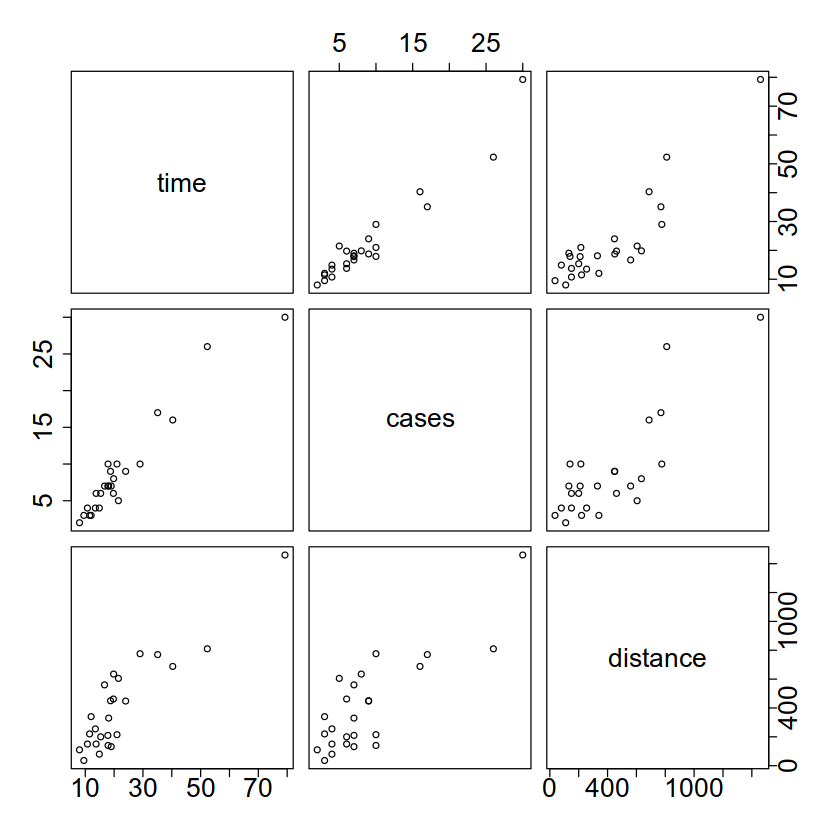

In [2]:
options(repr.plot.width=7, repr.plot.height=7)
pairs(data, cex.axis=2, cex.labels=2)  

In [3]:
# a modern 3D plotting library
# install.packages("plotly")
library(plotly)

Loading required package: ggplot2


Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout




In [4]:
p = plot_ly(data, x=~cases, y=~distance, z=~time, size=10, alpha=0.8, type = "scatter3d", mode = "markers") 
embed_notebook(p, width = 700, height = 700)

---

### Task 2

Fit a multiple linear regression model using the matrix approach

$$
\vec y = X \vec \beta + \vec \varepsilon
$$
where
$$
\vec y = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}  \qquad
X = \begin{bmatrix} 1 & x_{11} & x_{12} & \dots & x_{1p} \\ 1 & x_{21} & x_{22} & \dots & x_{2p} \\ \vdots & \vdots & \vdots && \vdots\\ 1 & x_{n1} & x_{n2} & \dots & x_{np} \end{bmatrix} \qquad
\vec \beta = \begin{bmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_p \end{bmatrix} \qquad
\vec \varepsilon = \begin{bmatrix} \varepsilon_1 \\ \varepsilon_2 \\ \vdots \\ \varepsilon_n \end{bmatrix} .
$$ 

The least squares estimate of $\vec\beta$ is given by

$$
\hat{\vec \beta} = C X^T \vec y \qquad\text{where}\qquad C = (X^T X)^{-1}
$$

In [5]:
y  = data$time      # responses
n  = length(y)      # number of cases

x0 = rep(1,n)       # vector of 1's    - the first  column of X
x1 = data$cases     # first predictor  - the second column of X
x2 = data$distance  # second predictor - the third  column of X
p  = 2              # number of predictors

X = cbind(x0,x1,x2) # design matrix
# X                 # uncomment to inspect the desing matrix

In [6]:
C = solve( t(X) %*% X )  # solve computes the inverse
C

,x0,x1,x2
x0,1.132152e-01,-4.448593e-03,-8.367257e-05
x1,-4.448593e-03,2.743783e-03,-4.785709e-05
x2,-8.367257e-05,-4.785709e-05,1.228745e-06


In [7]:
beta = C %*% t(X) %*% y  # the least squares estimates of regression parameters
round(beta, 3)

x0,2.341
x1,1.616
x2,0.014


In [8]:
Delivery = lm(time~cases+distance, data=data)  # verify using built-in functions
Delivery


Call:
lm(formula = time ~ cases + distance, data = data)

Coefficients:
(Intercept)        cases     distance  
    2.34123      1.61591      0.01438  


**Conclusions:**

On average:

- It takes 2.341 minutes (2 mins, 20.5 secs) for the delivery man to prepare the delivery. 

- Each additional case increases the delivery time by 1.616 minutes (1 min, 37 secs). 

- Each additional feet walked increases the delivery time by 0.014 minutes (0.84 seconds).

---

### Task 3

Find a 95% confidence interval for the slope $\beta_1$ associated to $x_1 = $ cases. You will need to use the following formulas:

$$
{\rm CI}(\beta_j) = \Big[\hat\beta_j - t_{\alpha/2, n-p-1} \cdot {\rm se}(\hat\beta_j) ,\; \hat\beta_j + t_{\alpha/2, n-p-1} \cdot {\rm se}(\hat\beta_j) \Big]
$$

where 

$$
\hat\beta_j = (C X^T \vec y)_{jj} \qquad 
{\rm se}(\hat\beta_j) = \sqrt{\hat\sigma^2\, c_{jj}} \qquad
\hat\sigma^2 = MS_E = \frac{\vec e^T \vec e}{n-p-1} \qquad
\vec e = \vec y - \hat{\vec y} \qquad
\hat{\vec y} = X \hat{\vec\beta}
$$

In [9]:
y.hat   = X %*% beta                 # fitted values
e       = y - y.hat                  # residuals
SigmaSq = sum(e**2) / (n-p-1)        # estimated variance
beta.se = sqrt( SigmaSq * diag(C) )  # estimates standard error of beta's

tcrit   = qt(1-0.05/2, n-p-1)        # critical t-value

CImin = (beta - tcrit * beta.se)[2]  # lower bound of CI - [2] gives second entry, i.e. for b1
CImax = (beta + tcrit * beta.se)[2]  # upper bound of CI - [2] gives second entry, i.e. for b1

sprintf("A 95%% CI for the slope associated with x1 is [%.3f, %.3f]", CImin, CImax)

[1] "A 95% CI for the slope associated with x1 is [1.262, 1.970]"

In [10]:
round(confint(Delivery),3)  # check using built-in functions

,2.5 %,97.5 %
(Intercept),0.067,4.616
cases,1.262,1.970
distance,0.007,0.022


**Extra.** Let's reproduce exactly the same table as ``confint()`` gives:

In [11]:
CImin = (beta - tcrit * beta.se)  # all three CImin's
CImax = (beta + tcrit * beta.se)  # all three CImax's
CI = data.frame(CImin,CImax, 
                row.names = c("(intercept)", "cases", "distance"))
colnames(CI) = c("2.5%", "97.5%")  
data.matrix(round(CI,3))          # vualia! 

,2.5%,97.5%
(intercept),0.067,4.616
cases,1.262,1.970
distance,0.007,0.022


**Conclusions:**

- There is a 95\% probability that a single case carried by the delivery man contributes from 1.262 to 1.970 minutes to the delivery time.

---

### Task 4

Find a 95% confidence interval for the mean delivery time of $x_1=8$ cases and where the distanced walked by the delivery man is $x_2 = 275$ feet. You will need to use the following formulas:

$$
{\rm CI}(\mu_0) = \Big[ \hat\mu_0 - t_{\alpha/2, n-p-1} \cdot {\rm se}(\hat\mu_0) ,\; \hat\mu_0 + t_{\alpha/2, n-p-1} \cdot {\rm se}(\hat\mu_0)  \Big]
$$
where 
$$
\hat\mu_0 = \vec x_0^T \hat{\vec\beta} \qquad
{\rm se}(\hat\mu_0) = \sqrt{\hat\sigma^2 \vec x_0^T  C \vec x_0}
$$


In [12]:
x0  = c(1, 8, 275) # x0=1, x1=8, x2=275
# ATTENTION! x0 is not neither a column vector, nor a row vector
# t(x0) is a row vector
# t(t(x0)) is a column vector
x0
t(x0)
t(t(x0))

[1]   1   8 275

1,8,275


1
8
275


In [13]:
x0  = c(1, 8, 275)  # new level of predictors 
mu0 = x0 %*% beta   # mean response at this level

mu0.se = sqrt( SigmaSq * ( x0 %*% C %*% x0 ) )  # R knows how to deal with this computation

CImin = mu0 - tcrit * mu0.se  # lower bound of CI
CImax = mu0 + tcrit * mu0.se  # uppoer bound of CI

sprintf("A 95%% CI for the mean response at x0 is [%.3f, %.3f]", CImin, CImax)

[1] "A 95% CI for the mean response at x0 is [17.654, 20.795]"

In [14]:
# verify using built-in functions
round(predict(Delivery, newdata=data.frame(cases=8, distance=275), 
              interval="confidence", level=0.95),3)

,fit,lwr,upr
1,19.224,17.654,20.795


In [15]:
# another way to state the same result
CImin = mu0 - tcrit * mu0.se
CImax = mu0 + tcrit * mu0.se
CI = data.frame(mu0,CImin,CImax)
colnames(CI) = c("Mean delivery time", "2.5%", "97.5%")  
data.matrix(round(CI,3))

Mean delivery time,2.5%,97.5%
19.224,17.654,20.795


**Conclusions:**

- There is a 95\% probability that the mean delivery time of $x_1 = 8$ cases, when the distance walked by the delivery man is $x_2 = 275$ feet, is between 17.654 and 20.795 minutes.

---

### Task 5

Find a 95% prediction interval for the delivery time of $x_1=8$ cases and where the distanced walked by the delivery man is $x_2 = 275$ feet. You will need to use the following formulas:

$$
{\rm PI}(y_0) = \Big[ \hat y_0 - t_{\alpha/2, n-p-1} \cdot {\rm se}(\hat y_0) ,\; \hat y_0 + t_{\alpha/2, n-p-1} \cdot {\rm se}(\hat y_0)  \Big]
$$
where 
$$
\hat y_0 = \vec x_0^T \hat{\vec\beta} \qquad
{\rm se}(\hat y_0) = \sqrt{\hat\sigma^2 (1 + \vec x_0^T  C \vec x_0)}
$$ 


In [16]:
x0 = c(1, 8, 275)  # new level of predictors 
y0 = x0 %*% beta   # predicted response at this level

y0.se = sqrt(  SigmaSq * ( 1 + t(x0) %*% C %*% x0 ) )

PImin = y0 - tcrit * y0.se
PImax = y0 + tcrit * y0.se

sprintf("A 95%% PI for a new observation at x0 is [%.3f, %.3f]", PImin, PImax)

[1] "A 95% PI for a new observation at x0 is [12.285, 26.164]"

In [17]:
round(predict(Delivery, newdata=data.frame(cases=8, distance=275), 
              interval="prediction", level=0.95),3)

,fit,lwr,upr
1,19.224,12.285,26.164


In [18]:
# another way to state the same result
PImin = y0 - tcrit * y0.se
PImax = y0 + tcrit * y0.se
PI = data.frame(mu0,PImin,PImax)
colnames(PI) = c("Predicted delivery time","2.5%", "97.5%")  
data.matrix(round(PI,3))

Predicted delivery time,2.5%,97.5%
19.224,12.285,26.164


**Conclusions:**

- There is a 95\% probability that a new delivery of $x_1 = 8$ cases, when the distance walked by the delivery man is $x_2 = 275$ feet, will take between 12.285 and 26.164 minutes.

---

**Extra.** Prediction interval for multiple levels.

In [19]:
# prepare a matrix of cases of interest

x0 = cbind(c(1, 8, 275),   # x0=1, x1=8  cases, x2=275 feet
           c(1, 10, 275),  # x0=1, x1=10 cases, x2=275 feet
           c(1, 12, 275),  # x0=1, x1=12 cases, x2=275 feet
           c(1, 22, 275))  # x0=1, x1=12 cases, x2=275 feet
t(x0)

1,8,275
1,10,275
1,12,275
1,22,275


In [20]:
y0 = t(x0) %*% beta  # predicted responses at the given levels

y0.se = sqrt( SigmaSq * ( 1 + diag( t(x0) %*% C %*% x0 ) ) )

PImin = y0 - tcrit * y0.se
PImax = y0 + tcrit * y0.se

PI = data.frame(y0, PImin, PImax, 
                row.names=c("8 cases, 275 feet", "10 cases, 275 feet", 
                            "12 cases, 275 feet", "22 cases, 275 feet"))
colnames(PI) = c("Predicted delivery time", "2.5%", "97.5%")
data.matrix(round(PI,3))

,Predicted delivery time,2.5%,97.5%
"8 cases, 275 feet",19.224,12.285,26.164
"10 cases, 275 feet",22.456,15.424,29.489
"12 cases, 275 feet",25.688,18.494,32.882
"22 cases, 275 feet",41.847,32.999,50.695


---